<a href="https://colab.research.google.com/github/vikrampal12345/Statistics/blob/main/2_Probability_distribution/1_Probability_density.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parametric Density Estimation

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import normal


In [ ]:
# loc = mean
# scale = std
sample = normal(loc = 50, scale=5, size=1000)
sample

In [ ]:
sample.mean()

np.float64(49.88625872189291)

(array([  3.,  12.,  51., 131., 266., 256., 177.,  78.,  19.,   7.]),
 array([32.53616104, 35.88695195, 39.23774285, 42.58853376, 45.93932466,
        49.29011557, 52.64090647, 55.99169737, 59.34248828, 62.69327918,
        66.04407009]),
 <BarContainer object of 10 artists>)

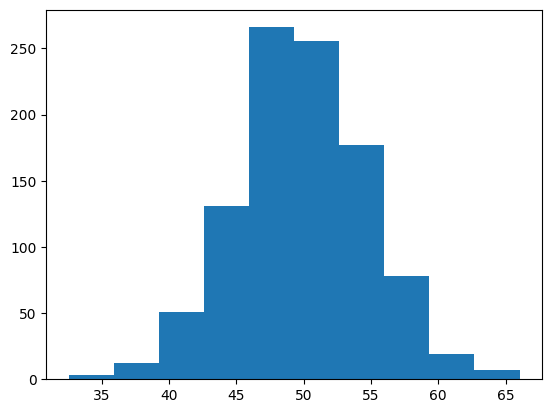

In [ ]:
# plot histogram to understand the distribution of data
plt.hist(sample, bins=10)

In [ ]:
# calculate sample mean and sample std dev

sample_mean = sample.mean()
sample_std = sample.std()

In [ ]:
# fit the distribution with the above parameters

from scipy.stats import norm
dist = norm(sample_mean, sample_std)

values = np.linspace(sample.min(), sample.max(), 100)

probabilities = [dist.pdf(value) for value in values]

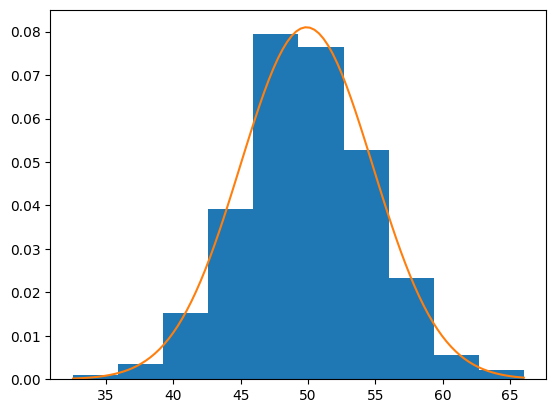

In [ ]:
# plot the histogram and pdf

plt.hist(sample, bins=10, density=True)
plt.plot(values, probabilities)

/tmp/ipykernel_641/3900856415.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sample)


<Axes: ylabel='Density'>

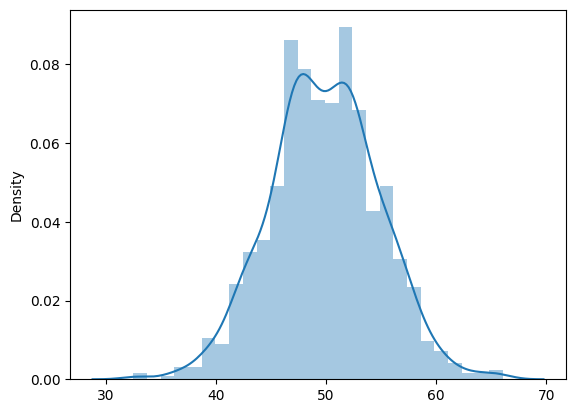

In [ ]:
import seaborn as sns

sns.distplot(sample)

<Axes: ylabel='Count'>

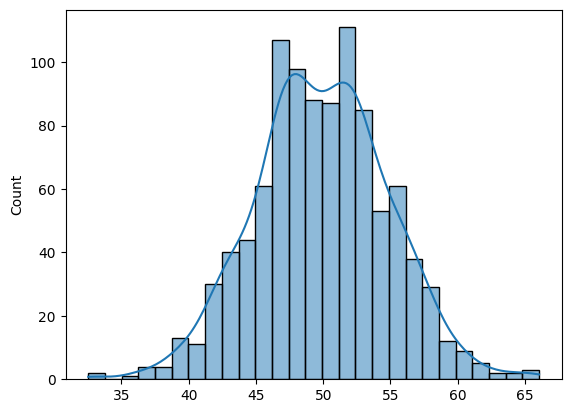

In [ ]:
sns.histplot(sample, kde=True)

<Axes: ylabel='Density'>

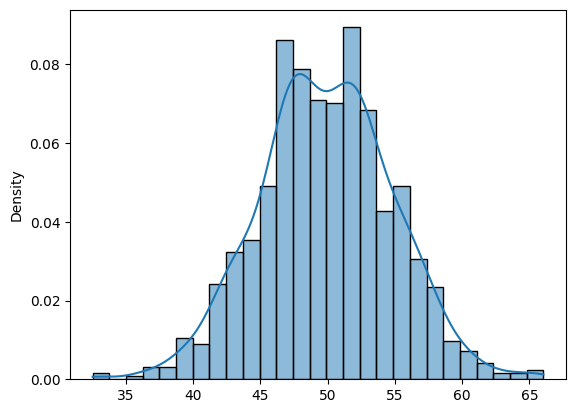

In [ ]:
sns.histplot(sample, kde=True, stat = 'density')

# KDE

In [ ]:
# generate a sample
sample1 = normal(loc=20, scale=5, size=300)
sample2 = normal(loc=40, scale=5, size=700)

sample = np.hstack((sample1, sample2))

(array([ 2.,  1.,  0.,  4.,  4.,  3.,  4.,  6., 12., 10., 16., 13., 21.,
        22., 25., 22., 26., 20., 22., 18., 13., 13., 14., 14.,  4., 11.,
        21., 13., 20., 19., 35., 47., 55., 52., 49., 51., 52., 49., 45.,
        32., 27., 29., 31., 11., 19.,  5.,  6.,  7.,  2.,  3.]),
 array([ 4.91302977,  5.9065739 ,  6.90011804,  7.89366217,  8.8872063 ,
         9.88075044, 10.87429457, 11.8678387 , 12.86138283, 13.85492697,
        14.8484711 , 15.84201523, 16.83555937, 17.8291035 , 18.82264763,
        19.81619177, 20.8097359 , 21.80328003, 22.79682416, 23.7903683 ,
        24.78391243, 25.77745656, 26.7710007 , 27.76454483, 28.75808896,
        29.7516331 , 30.74517723, 31.73872136, 32.73226549, 33.72580963,
        34.71935376, 35.71289789, 36.70644203, 37.69998616, 38.69353029,
        39.68707442, 40.68061856, 41.67416269, 42.66770682, 43.66125096,
        44.65479509, 45.64833922, 46.64188336, 47.63542749, 48.62897162,
        49.62251575, 50.61605989, 51.60960402, 52.60314815,

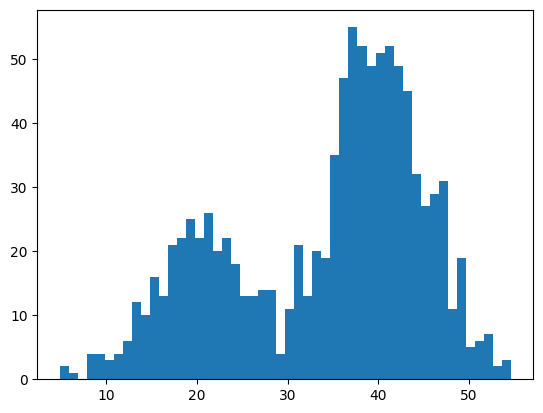

In [ ]:
plt.hist(sample,bins=50)

In [ ]:
from sklearn.neighbors import KernelDensity

model = KernelDensity(bandwidth=3, kernel = 'gaussian')

# convert data to a 2D array

sample = sample.reshape((len(sample),1))

model.fit(sample)

KernelDensity(bandwidth=3)

In [ ]:
values = np.linspace(sample.min(), sample.max(), 100)
values = values.reshape((len(values),1))

In [ ]:
probabilities = model.score_samples(values)   # it gives log
probabilities = np.exp(probabilities)  # so that exp because nullify the log

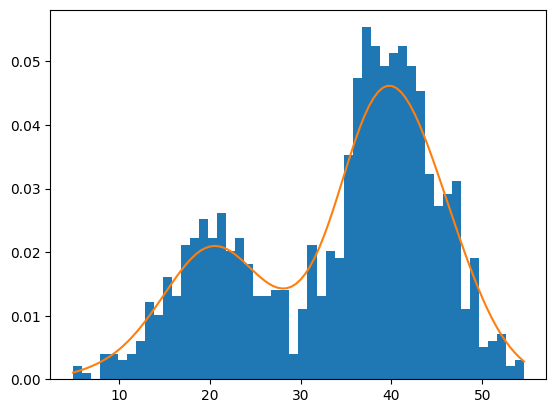

In [ ]:
plt.hist(sample, bins=50, density=True)
plt.plot(values[:], probabilities)
plt.show()

In [ ]:
sns.kdeplot(sample.reshape(1000), )